In [1]:
import os 

#Insert API key
# os.environ['OPENAI_API_KEY'] = 'sk-GSJA3k3Re1j05j0K7es3oumDBFJl5C8kn8ronDnqPmOenE5G'
os.environ['OPENAI_API_KEY'] = 'sk-5T6oMdbJnNP23WEC5psT4I8sZyEd90Nve1YquVKdj9coHpIy'
os.environ['OPENAI_API_BASE'] = 'https://api.chatanywhere.org/v1'

In [2]:
import sys
sys.path.append("../")

#Import your prompt - we have a system message, starting prompt and iteration prompt
# ADSC is hard search with all operators (A), 
# and all tools (D (data), C (context), S (scratchpad))

from prompt_airfog import SYS_MSG, IGNITE, ITER


In [6]:
#Import experiment class
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 

#experiment file all different experiment settings in Python class
from experiment import airFog, airFogWithNMSE

In [7]:
#Import data
import pandas as pd
import json

df = pd.read_csv('../AirFogSim/output/global_data.csv')
data = df.to_dict(orient='list')

all_keys = list(data.keys())
all_values = list(data.values())

with open('../AirFogSim/output/context_summary.json', 'r') as f:
    context_summary = json.load(f)

y1 = all_values[7][1:]  # compute_load_avg
x11 = all_values[1][:len(y1)]   # current_task_success_ratio
x12 = all_values[8][:len(y1)]   # current_vehicle_density
x13 = all_values[9][:len(y1)]   # current_uav_density
x14 = all_values[10][:len(y1)]  # junction_0_vehicle_count
x15 = all_values[11][:len(y1)]  # junction_1_vehicle_count
x16 = all_values[12][:len(y1)]  # junction_2_vehicle_count

y2 = all_values[4][1:]  # avg_V2U_rate
x21 = all_values[8][:len(y2)]   # current_vehicle_density
x22 = all_values[9][:len(y2)]   # current_uav_density
x23 = all_values[7][:len(y2)]  # current_compute_load_avg

y3 = all_values[1][1:]  # task_success_ratio
x31 = all_values[4][:len(y3)]   # current_avg_V2U_rate
x32 = all_values[5][:len(y3)]   # current_avg_V2I_rate
x33 = all_values[7][:len(y3)]   # current_compute_load_avg

y4 = all_values[9][1:]  # uav_density
x41 = all_values[6][:len(y4)]   # current_avg_U2I_rate
x42 = all_values[7][:len(y4)]  # current_compute_load_avg
x43 = [context_summary["nonfly_zones"]["area_ratio"]] * len(y4)    # nonfly_zones.area_ratio

dep_vars = list(map(str, [y1, y2, y3, y4]))
indep_vars = list(map(list, (map(str, [x11, x12, x13, x14, x15, x16]),
                                map(str, [x21, x22, x23]),
                                map(str, [x31, x32, x33]),
                                map(str, [x41, x42, x43]))))


background= """
The data is collected from a low-altitude vehicular network where vehicles and uavs collaborate to complete computational tasks under limited bandwidth and computational resources  
For each time slot, key indicators, such as task success ratio, average V2U rate, and UAV density, are recorded. 
The 4 patterns you need to analyze are all about the relationship between one key indicator of the next slot and a few key indicators of the current slot.

Pattern 1: Predict the average compute load of the next time slot based on the current task success ratio, vehicle density, UAV density and junction vehical counts. 
- Independent variable (x1): Current task success ratio.
- Independent variable (x2): Current vehicle density.
- Independent variable (x3): Current UAV density.
- Independent variable (x4): Current Junction 0 vehicle count.
- Independent variable (x5): Current Junction 1 vehicle count.
- Independent variable (x6): Current Junction 2 vehicle count.
- Dependent variable (y): Average compute load of the next time slot.

Pattern 2: Predict the average V2U rate of the next time slot based on the current vehicle density, UAV density and compute load.
- Independent variable (x1): Current vehicle density.
- Independent variable (x2): Current UAV density.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Average V2U rate of the next time slot.

Pattern 3: Predict the task success ratio of the next time slot based on the current average V2U rate, average V2I rate and compute load.
- Independent variable (x1): Current average V2U rate.
- Independent variable (x2): Current average V2I rate.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Task success ratio of the next time slot.

Pattern 4: Predict the UAV density of the next time slot based on the current average U2I rate, compute load and nonfly zone area ratio.
- Independent variable (x1): Current average U2I rate.
- Independent variable (x2): Current average compute load.
- Independent variable (x3): Nonfly zone area ratio.
- Dependent variable (y): UAV density of the next time slot.
"""
augmentation = f"There are some context information about the data which may help you to understand the data better:\n{context_summary}"

In [8]:
# Without context augmentation
context = background
print(context)


The data is collected from a low-altitude vehicular network where vehicles and uavs collaborate to complete computational tasks under limited bandwidth and computational resources  
For each time slot, key indicators, such as task success ratio, average V2U rate, and UAV density, are recorded. 
The 4 patterns you need to analyze are all about the relationship between one key indicator of the next slot and a few key indicators of the current slot.

Pattern 1: Predict the average compute load of the next time slot based on the current task success ratio, vehicle density, UAV density and junction vehical counts. 
- Independent variable (x1): Current task success ratio.
- Independent variable (x2): Current vehicle density.
- Independent variable (x3): Current UAV density.
- Independent variable (x4): Current Junction 0 vehicle count.
- Independent variable (x5): Current Junction 1 vehicle count.
- Independent variable (x6): Current Junction 2 vehicle count.
- Dependent variable (y): Avera

In [9]:
# With context augmentation
context = f"{background}\n{augmentation}"
print(context)


The data is collected from a low-altitude vehicular network where vehicles and uavs collaborate to complete computational tasks under limited bandwidth and computational resources  
For each time slot, key indicators, such as task success ratio, average V2U rate, and UAV density, are recorded. 
The 4 patterns you need to analyze are all about the relationship between one key indicator of the next slot and a few key indicators of the current slot.

Pattern 1: Predict the average compute load of the next time slot based on the current task success ratio, vehicle density, UAV density and junction vehical counts. 
- Independent variable (x1): Current task success ratio.
- Independent variable (x2): Current vehicle density.
- Independent variable (x3): Current UAV density.
- Independent variable (x4): Current Junction 0 vehicle count.
- Independent variable (x5): Current Junction 1 vehicle count.
- Independent variable (x6): Current Junction 2 vehicle count.
- Dependent variable (y): Avera

Running experiment 1...


e:\Tongji\Junior2\专业方向综合项目\Low-Dynamic-Traffic-Analysis\Prediction\experiment.py:37: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.equation_generation_chain = LLMChain(llm=self.llm, prompt=self.startup_promt)
e:\Tongji\Junior2\专业方向综合项目\Low-Dynamic-Traffic-Analysis\Prediction\experiment.py:59: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  StartupOutput = self.equation_generation_chain.run(


Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Pattern 1: Analysis of the first pattern focuses on predicting the average compute load of the next time slot based on several current indicators. Given the complexity and number of independent variables (x1 to x6), the aim is to establish a simplified and plausible relationship. The dataset shows that the current task success ratio (x1) and vehicle density (x2) are likely to have a more direct influence on the compute load. Other variables like junction vehicle counts (x4 to x6) could be contributing factors but are less explicitly related.

Pattern 2: For the second pattern, the average V2U rate needs to be predicted based on vehicle density (x1), UAV density (x2), and compute load (x3). The compute load (x3) is expected to play a significant role, given that higher compute demands could impact the communication load and hence the V2U rate. Vehicle density (x1) is another critical factor, whereas UAV density (x

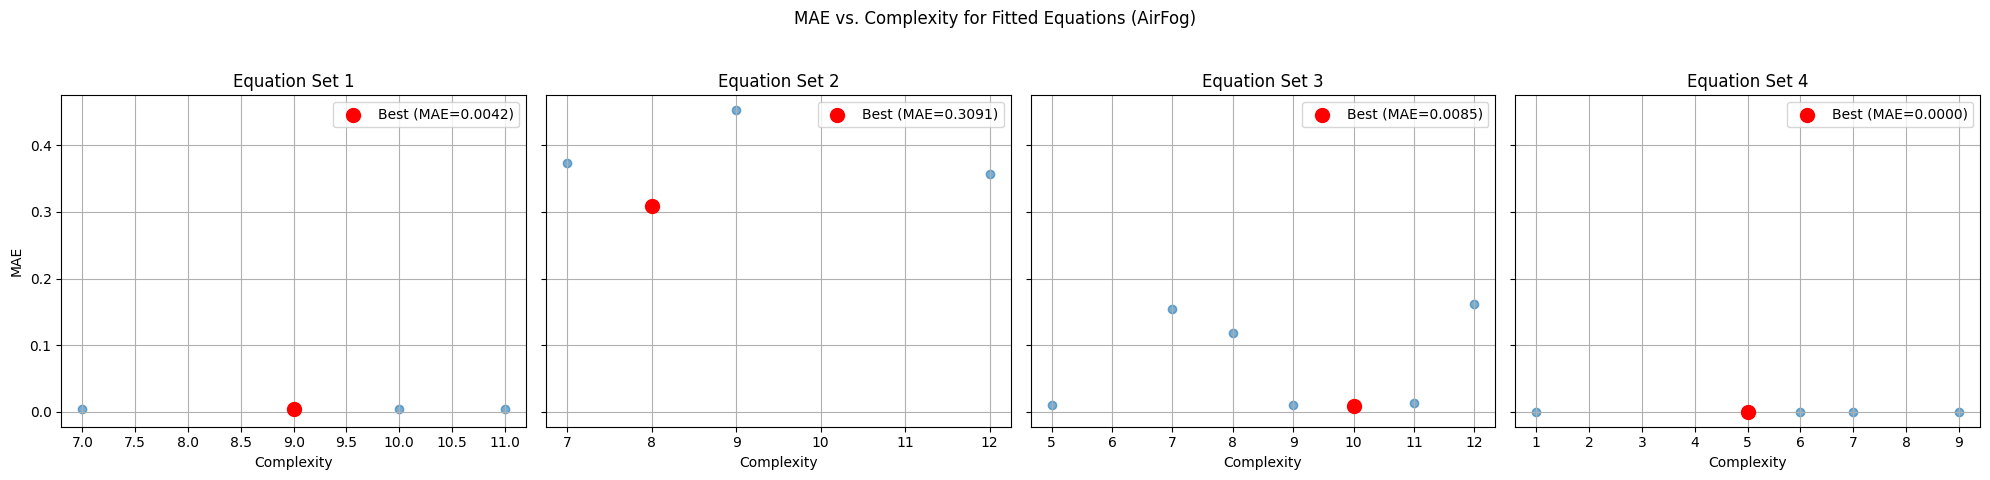

Experiment 1 finished.
Running experiment 2...
Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Pattern 1: 

The target variable is "average compute load of the next time slot" (y), and independent variables are the current "task success ratio" (x1), "vehicle density" (x2), "UAV density" (x3), "Junction 0 vehicle count" (x4), "Junction 1 vehicle count" (x5), and "Junction 2 vehicle count" (x6). 

1. y appears to have small values, indicating a possible relationship with the independent variables that involve scaling down or division. 
2. Observing the pattern, it seems that some form of interaction or combination of these variables might be relevant.
3. x1, x4, x5, and x6 have repeated values which might suggest limited influence or need for a non-linear transformation.

Pattern 2: 

The target here is the "average V2U rate of the next time slot" (y), and independent variables are "vehicle density" (x1), "UAV density" (x2), and "average compute load" (x3).

1. 

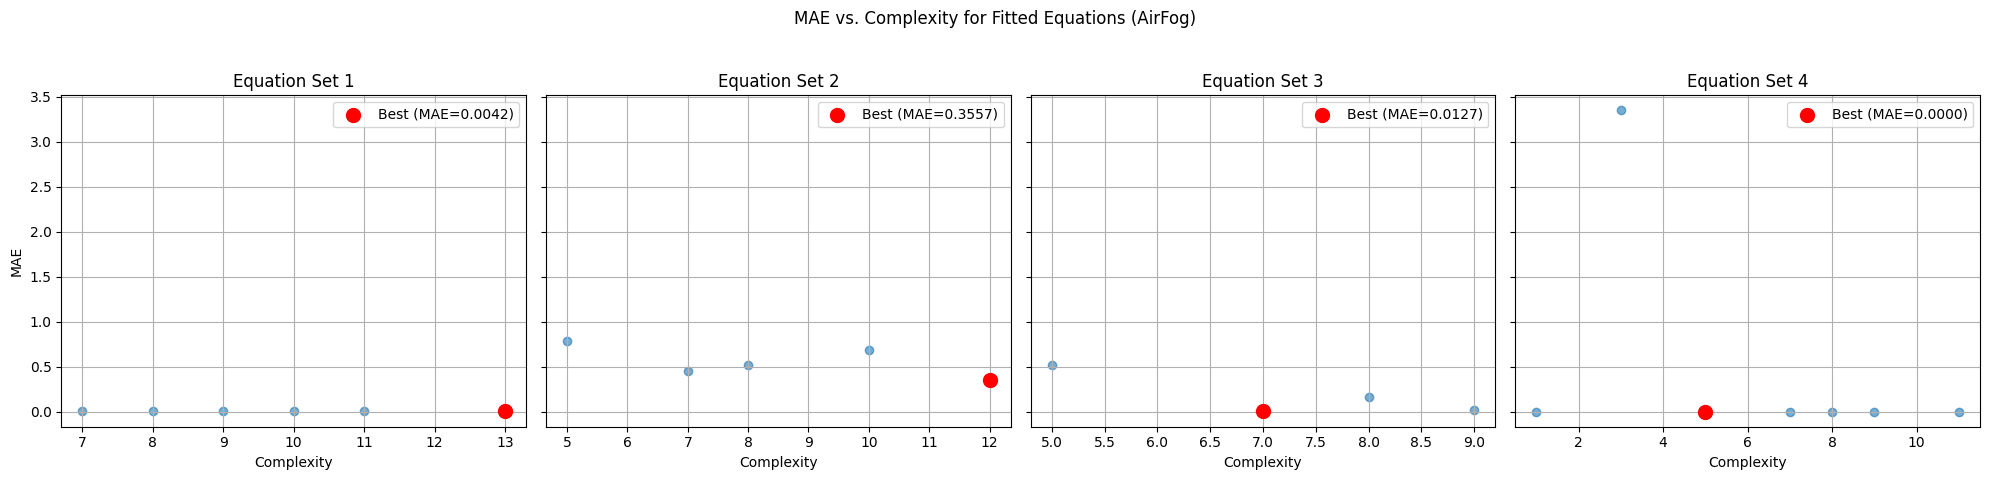

Experiment 2 finished.
Running experiment 3...
Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Pattern 1: The dependent variable \( y \) appears to be related to a combination of \( x1 \), \( x2 \), and possibly \( x4 \), \( x5 \), and \( x6 \). Observing the independent variables, \( x2 \) seems to have a strong correlation with the pattern in \( y \), as it generally increases with the increase in \( x2 \). A potential functional form could be a linear combination of these variables, or a non-linear transformation might be needed for a better fit.

For the second pattern, the dependent variable \( y \) seems to have a strong correlation with the independent variable \( x1 \) as both show an increasing trend. \( x3 \), the average compute load, could also be impacting the output \( y \). The relationship might be of a polynomial or a logarithmic form.

In the third pattern, the task success ratio \( y \) might be influenced by the average V2U rate \( x1 \) an

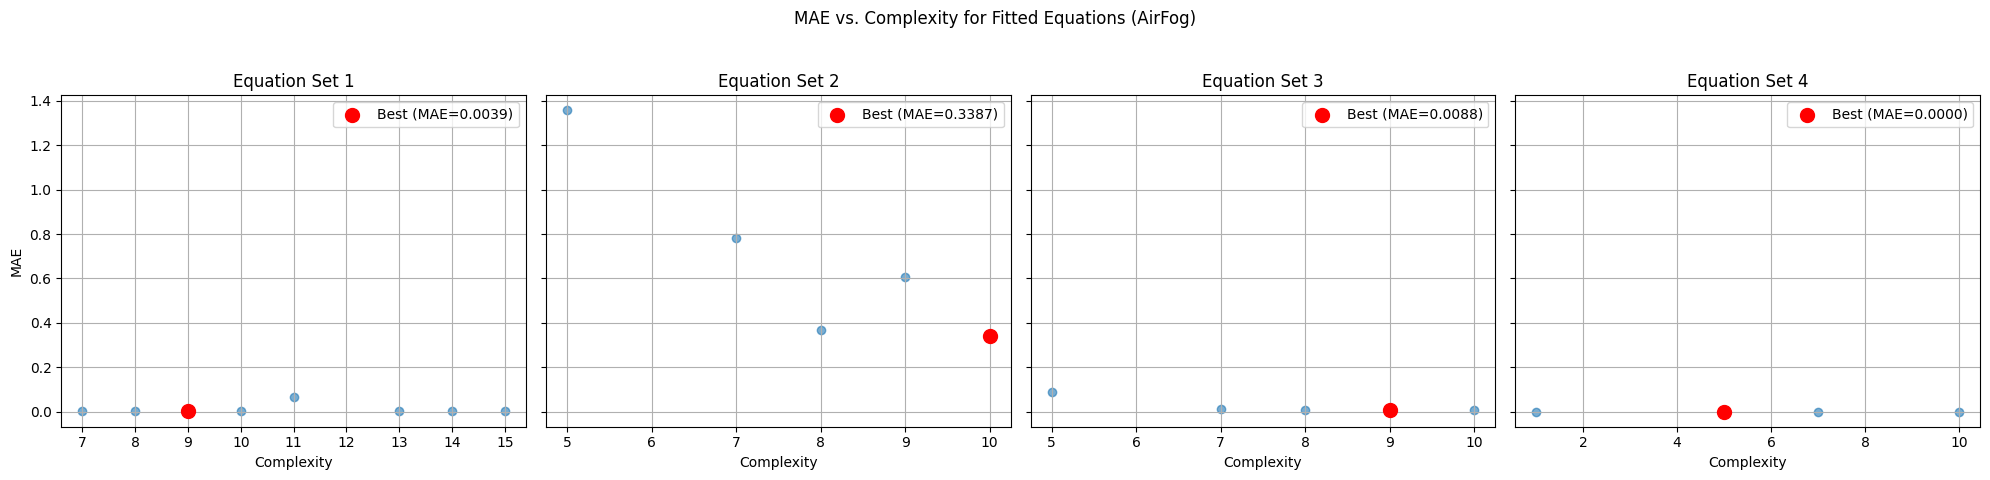

Experiment 3 finished.


In [12]:
# Using MAE as the error function

import json
#No. of expressions generated in each LLM call
N = 3
temp = 0.7
model = "gpt-4o"

#Increase iterations here
total_iterations = 5 

sys_msg= SYS_MSG
ignite_msg = IGNITE
iter_msg = ITER

results_fromAllruns = []
iteration_infos_fromAllruns = []


# Run the experiment n times
for i in range(3):
    print(f"Running experiment {i+1}...")

    # Create a new instance of the experiment class with your settings
    #options = allTools, noContext, noData, noScratchpad
    experiment = airFog(dep_vars, indep_vars, N, temp, context, sys_msg, ignite_msg, iter_msg, model)
    # Run the experiment and store the results
    results, all_expressions, iteration_info, usage_list, total_chain_run_time, all_expressionsLLM = experiment.run(total_iterations)
    
    results_fromAllruns.append({
        'CombResults': results, 
        'all_expressions': all_expressions, 
        'usage_list': usage_list, 
        'total_chain_run_time': total_chain_run_time,
        'LLM raw expressions': all_expressionsLLM
    })
    
    # Store the iteration info
    iteration_infos_fromAllruns.append(iteration_info)

    # print(f"Experiment {i+1} finished. Cost: {experiment.cost()}")
    print(f"Experiment {i+1} finished.")

    directory_path = "tests/AirFog"
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)  # This will create all intermediate-level directories needed to contain the leaf directory

    with open(f"{directory_path}/PromptsUsed.txt", 'w') as f:
        f.write(f"##Sytstem Message## {SYS_MSG}\n")
        f.write(f"##Starting Prompt## {IGNITE}\n")
        f.write(f"##Iteration Prompt## {ITER}\n")

    with open(f"{directory_path}/run{i+1}.txt", 'w') as f:
        f.write("Final Results:\n")
        for res in results:
            json.dump(res, f, indent=2)
            f.write("\n")
        # f.write(f"Cost for this run: ${experiment.cost()}\n")
        f.write(f"Total chain run time: {total_chain_run_time} seconds.\n")
        f.write("\n\nIteration Information:\n")
        for info in iteration_info:
            json.dump(info, f, indent=2)
            f.write("\n")

In [ ]:
# Using fitness function with NMSE as the error function

import json
#No. of expressions generated in each LLM call
N = 3
temp = 0.7
model = "gpt-4o"

#Increase iterations here
total_iterations = 5 

sys_msg= SYS_MSG
ignite_msg = IGNITE
iter_msg = ITER

results_fromAllruns = []
iteration_infos_fromAllruns = []


# Run the experiment n times
for i in range(3):
    print(f"Running experiment {i+1}...")

    # Create a new instance of the experiment class with your settings
    #options = allTools, noContext, noData, noScratchpad
    experiment = airFogWithNMSE(dep_vars, indep_vars, N, temp, context, sys_msg, ignite_msg, iter_msg, model)
    # Run the experiment and store the results
    results, all_expressions, iteration_info, usage_list, total_chain_run_time, all_expressionsLLM = experiment.run(total_iterations)
    
    results_fromAllruns.append({
        'CombResults': results, 
        'all_expressions': all_expressions, 
        'usage_list': usage_list, 
        'total_chain_run_time': total_chain_run_time,
        'LLM raw expressions': all_expressionsLLM
    })
    
    # Store the iteration info
    iteration_infos_fromAllruns.append(iteration_info)

    # print(f"Experiment {i+1} finished. Cost: {experiment.cost()}")
    print(f"Experiment {i+1} finished.")

    directory_path = "tests/AirFog"
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)  # This will create all intermediate-level directories needed to contain the leaf directory

    with open(f"{directory_path}/PromptsUsed.txt", 'w') as f:
        f.write(f"##Sytstem Message## {SYS_MSG}\n")
        f.write(f"##Starting Prompt## {IGNITE}\n")
        f.write(f"##Iteration Prompt## {ITER}\n")

    with open(f"{directory_path}/run{i+1}.txt", 'w') as f:
        f.write("Final Results:\n")
        for res in results:
            json.dump(res, f, indent=2)
            f.write("\n")
        # f.write(f"Cost for this run: ${experiment.cost()}\n")
        f.write(f"Total chain run time: {total_chain_run_time} seconds.\n")
        f.write("\n\nIteration Information:\n")
        for info in iteration_info:
            json.dump(info, f, indent=2)
            f.write("\n")